# Residential Solar Growth Model


**Objectives**

Create explanatory model for Solar growth rate based on socieconomic factors. 

**Key Outputs**

We create a Spatial Durbin model for Solar growth rate accounting for spatial dependence. 

**Methodology**

Spatial Weights Construction:
- WA, NT states are removed being out of AEMO regulation. TAS removed being disconnected from the mainland. 
- Queen contiguity followed by KNN (n=2) matching to connect islands. 

Baseline Model for solar adoption is created using the following steps:
1. Correlation was identified between solar growth rate and socioeconomic factors.
2. Missing data imputed using nearest neighbour imputation. 
3. Feature selection based on Lasso regression. 
4. OLS fit on selected variables


The residuals on the baseline model was tested for spatial autocorrelation using global Morans I. To determine the origin of the spatial autocorrealtion, we use a lagrange multiplier test. This reveals that spatial autocorrelation is due to both errors terms and spatial leakage (lag in dependence variables). Thus we fit a SARAR model. However the model is unable to completely remove spatial autocorrelation. We fit a spatial Durbin model as an alternative and find that the residuals are greatly reduced albeit still statistically significant. 

The Durbin model indicates that all variables have approximately equal direct (within same LGA) and indirect effects (adjacent LGAs) on the solar adoption rate. 


**Data**
- Geospatial data for LGAs obtained from https://digital.atlas.gov.au/datasets/local-government-area-geoscape-administrative-boundaries/explore/. 
- Solar and Battery adoption metrics obtained from outputs of "2_metrics.ipynb". 
- Socioeconomic data queried from SQlite database (originally obtained from ABS data). 


In [302]:
import yaml
from sqlalchemy import create_engine

import pandas as pd
import geopandas as gpd

import numpy as np
np.random.seed(42)
import matplotlib.pyplot as plt
import seaborn as sns

from libpysal.weights import W
from libpysal.weights import KNN

import libpysal
from esda.moran import Moran

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_validate
import statsmodels.api as sm
import numpy as np


We first import geospatial data for LGAs. The analysis is conducted across Australian LGAs, however since AEMO does not regulate WA and NT, we remove these states from the geometry. 

In [303]:
# Import Data
gdf = gpd.read_file(filename="../data/spatial/LGA_2021_SHP.zip")

# Print missing geometries
lga_missing_geom = gdf[gdf['geometry'].isna()==True]['LGA_NAME21']
print("LGAs with missing geometries:")
print(lga_missing_geom)

# Remove NAs (offshore/non standard addresses)
gdf = gdf.dropna(subset='geometry')

# Remove WA, NT and TAS (not under AEMO regulation and TAS is disconnected from mainland)
gdf = gdf[~gdf['STE_NAME21'].isin(['Western Australia','Northern Territory','Tasmania'])].reset_index(drop=True)


LGAs with missing geometries:
129                    No usual address (NSW)
130     Migratory - Offshore - Shipping (NSW)
211                   No usual address (Vic.)
212    Migratory - Offshore - Shipping (Vic.)
291                    No usual address (Qld)
292     Migratory - Offshore - Shipping (Qld)
364                     No usual address (SA)
365      Migratory - Offshore - Shipping (SA)
505                     No usual address (WA)
506      Migratory - Offshore - Shipping (WA)
536                   No usual address (Tas.)
537    Migratory - Offshore - Shipping (Tas.)
557                     No usual address (NT)
558      Migratory - Offshore - Shipping (NT)
560                    No usual address (ACT)
561     Migratory - Offshore - Shipping (ACT)
563                     No usual address (OT)
564      Migratory - Offshore - Shipping (OT)
565                         Outside Australia
Name: LGA_NAME21, dtype: str


Next we import 
1. Residential Solar and Battery Adoption metrics for the latest year. 
2. Socioeconomic data queried from the SQLite database, taking a median over the previous three years. 

The data is then combined using an inner join on LGAs to create complete datasets. 

The combined data is left joined to the LGA geospatial dataset. 

In [304]:
# --- Import Data --- #

# Import Residential Solar and Battery Adoption
res_df = pd.read_parquet("../data/processed/resmetrics_data.parquet")


# Query socioeconomic data
with open("../config.yaml", "r") as f:
    c = yaml.safe_load(f)['sql_config']


engine = create_engine(f"postgresql://{c['usr']}:{c['password']}@{c['server']}:{c['port']}/{c['dbname']}")

derr_df = pd.read_sql("SELECT * FROM processed.fact_derr",engine)
population_df = pd.read_sql("SELECT * FROM processed.dim_population",engine)
economy_df = pd.read_sql("SELECT * FROM processed.dim_economic",engine)
region_df = pd.read_sql_query("SELECT * FROM processed.dim_region", engine)
dataitem_df = pd.read_sql_query("SELECT * FROM processed.dim_dataitem", engine)

# --- Combine Data --- #

# Take median over years
population_median_df = (
    population_df
    .drop(labels='year',axis=1)
    .groupby(by='lga')
    .median()
)

economic_median_df = (
    economy_df
    .drop(labels='year', axis=1)
    .groupby(by='lga')
    .median()
)

# Combine economic and population data 
lga_df = pd.merge(
    left=population_median_df,
    right=economic_median_df,
    how='inner',
    on='lga'
).reset_index()

# Combine with residential solar and battery metrics 
full_df = pd.merge(
    left=lga_df,
    right=res_df[res_df['year']==2024],
    how='inner',
    on='lga'
)

# Add geometry 
gdf_sel = gdf[['LGA_CODE21','LGA_NAME21','STE_NAME21','geometry']]
gdf_sel.columns = ['lga','name','state','geometry']


full_gdf = gdf_sel.merge(
    right=full_df,
    how='left',
    on='lga'
)

 Spatial weights matrix are constructed on the LGAs using Queen contiguity. Any islands are connected based on two closest nearest neighbours. 

In [305]:
# Reproject to GDA94
if full_gdf.crs.to_epsg() != 3577:
    metrics_gdf = full_gdf.to_crs(3577)

# Calculate Queen base contiguity matrix
w = libpysal.weights.Queen.from_dataframe(metrics_gdf)

clean_gdf = full_gdf.copy()

# Identify and remove islands
while w.islands:
    print(f"Islands found: {clean_gdf.loc[w.islands, 'name'].tolist()}")
    clean_gdf = clean_gdf.drop(index=w.islands).reset_index(drop=True)
    w = libpysal.weights.Queen.from_dataframe(clean_gdf)
  

print(f"Final LGA count: {len(clean_gdf)}")
print(f"LGAs removed: {len(full_gdf) - len(clean_gdf)}")

# Transform
w.transform = 'r'
full_gdf = clean_gdf.copy()



/var/folders/hv/06ql3rk924l7p8lskj2gfm740000gn/T/ipykernel_46993/858340576.py:6: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w = libpysal.weights.Queen.from_dataframe(metrics_gdf)
/Users/hoseawondo/NextCloud/Projects/PortfolioProjects/Energy/.venv/lib/python3.12/site-packages/libpysal/weights/contiguity.py:347: UserWarning: The weights matrix is not fully connected: 
 There are 7 disconnected components.
 There are 6 islands with ids: 256, 263, 278, 310, 358, 359.
  W.__init__(self, neighbors, ids=ids, **kw)
/var/folders/hv/06ql3rk924l7p8lskj2gfm740000gn/T/ipykernel_46993/858340576.py:14: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w = libpysal.weights.Queen.from_dataframe(clean_gdf)


Islands found: ['Mornington', 'Palm Island', 'Torres Strait Island', 'Kangaroo Island', 'Christmas Island', 'Cocos Islands']
Final LGA count: 356
LGAs removed: 6


## Exploratory Data Analysis

In this section, we perform an exploratory data analysis by checking statistics, the distribution of each variables and detecting NAs. A Correlation heatmap is produced to identify correlation between variables. 

In [306]:
# Print basic statistics 
full_gdf.describe()

,total_population,population_density,median_age,median_household_income,certificate,adv_diploma,bachelor_degree,graduate_diploma,postgraduate,total_businesses,...,GrowthBattery,PenSolar,CPDSolar,CPCSolar,GrowthSolar,PenOther,CPDOther,CPCOther,GrowthOther,BSR
count,3.450000e+02,325.000000,345.000000,345.000000,344.000000,345.000000,345.000000,338.000000,340.000000,343.000000,...,345.000000,3.450000e+02,3.450000e+02,345.000000,345.000000,345.000000,345.000000,345.000000,3.450000e+02,345.000000
mean,6.523008e+04,612.235385,42.628696,962.463768,21.104651,8.155652,12.760870,1.962722,4.103235,6483.670554,...,1004.604277,1.163281e+00,6.124431e+00,5.313105,11758.608763,0.000162,0.001774,20.023808,-8.876745e+01,0.034158
std,1.111599e+05,1338.165883,6.404310,265.345331,5.336095,1.827560,7.343804,0.972821,4.110992,11738.482960,...,2349.513977,2.005308e+00,9.701859e+00,0.883210,26655.072244,0.000454,0.011576,185.760608,1.338958e+03,0.031960
min,1.020000e+02,0.100000,23.300000,403.000000,6.300000,1.800000,1.000000,0.500000,0.500000,5.000000,...,-1.663418,5.429960e-13,3.021836e-12,3.197761,-105.948522,0.000000,0.000000,0.000000,-2.098233e+04,0.000000
25%,6.463000e+03,1.700000,38.100000,791.000000,18.975000,6.800000,8.100000,1.200000,1.400000,864.000000,...,7.972109,5.609584e-01,2.757527e+00,4.839119,330.183239,0.000000,0.000000,0.000000,0.000000e+00,0.012122
50%,2.253800e+04,10.000000,42.100000,920.000000,22.800000,8.100000,9.800000,1.700000,2.400000,2201.000000,...,235.700498,9.059743e-01,4.761690e+00,5.309534,3324.838810,0.000000,0.000000,0.000000,0.000000e+00,0.023901
75%,7.843700e+04,338.500000,47.200000,1060.000000,24.500000,9.600000,14.900000,2.500000,4.900000,6950.000000,...,952.009489,1.264567e+00,6.713108e+00,5.674428,12375.175215,0.000036,0.000164,5.000000,1.198922e-09,0.045108
max,1.283432e+06,8518.800000,63.800000,2097.000000,32.000000,12.400000,37.100000,5.100000,18.600000,135490.000000,...,20918.034465,2.579961e+01,1.398413e+02,12.803107,299450.181195,0.003964,0.199010,2000.000000,4.359823e+03,0.151323


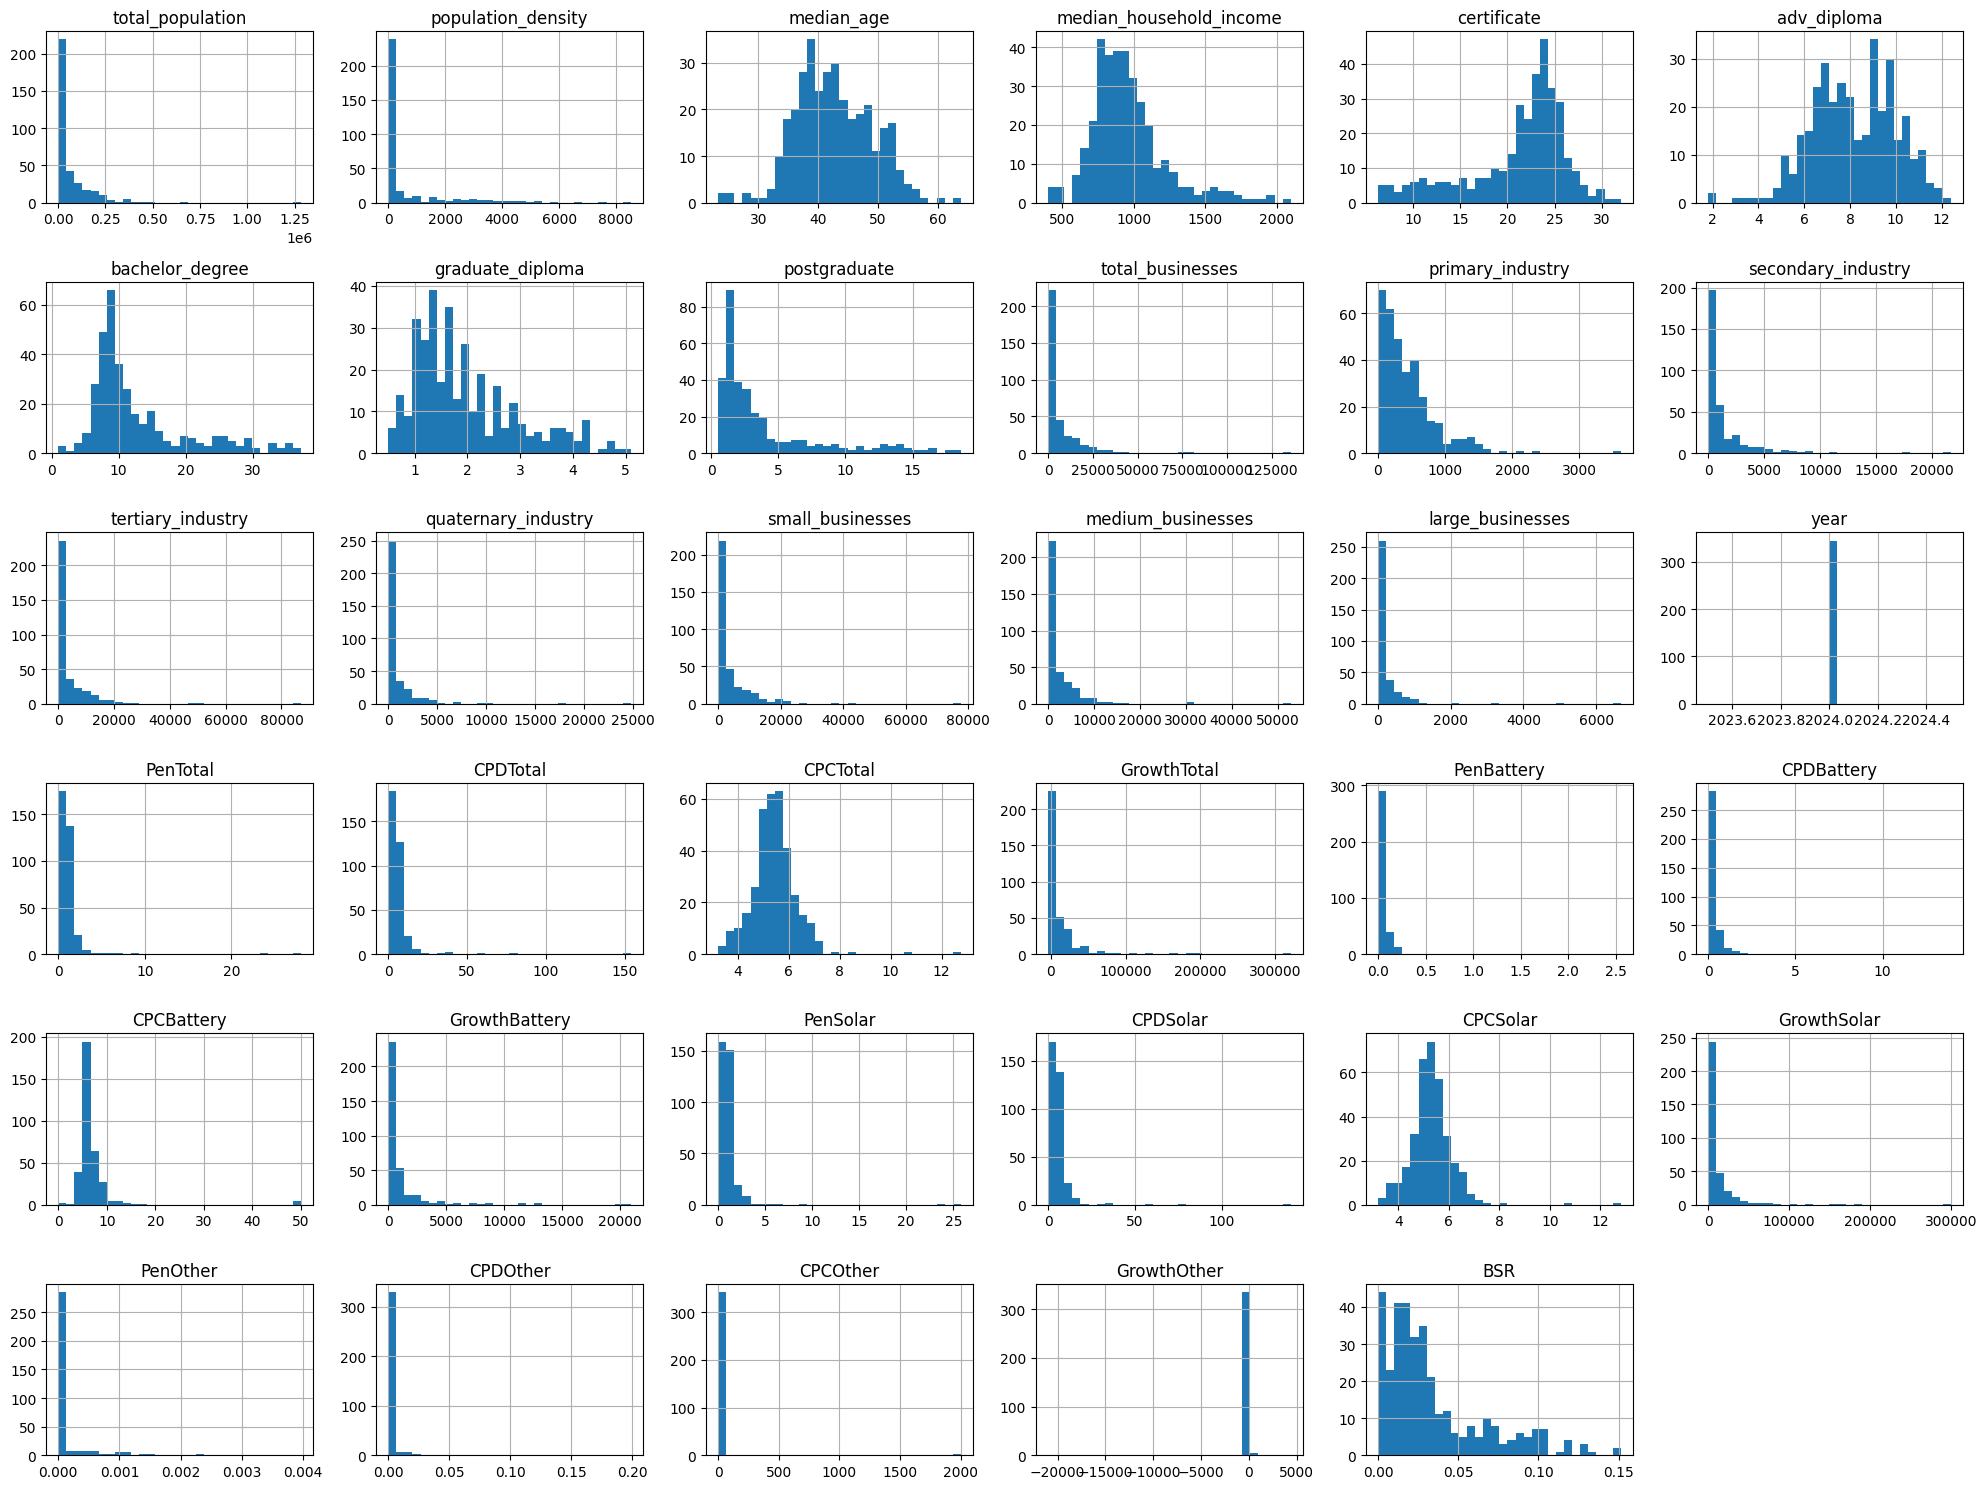

In [307]:
# Plot histograms of features
full_gdf.hist(figsize=(20, 15), bins=30)
plt.tight_layout()
plt.show()

In [308]:
# Check NAs
full_gdf.isna().sum()

lga                         0
name                        0
state                       0
geometry                    0
total_population           11
population_density         31
median_age                 11
median_household_income    11
certificate                12
adv_diploma                11
bachelor_degree            11
graduate_diploma           18
postgraduate               16
total_businesses           13
primary_industry           16
secondary_industry         15
tertiary_industry          13
quaternary_industry        18
small_businesses           13
medium_businesses          13
large_businesses           17
year                       11
PenTotal                   11
CPDTotal                   11
CPCTotal                   11
GrowthTotal                11
PenBattery                 11
CPDBattery                 11
CPCBattery                 11
GrowthBattery              11
PenSolar                   11
CPDSolar                   11
CPCSolar                   11
GrowthSola

NAs are present throughout the data. The NAs make up a small proportion of the data and are randomly distributed. We can therefore look to impute the NAs using nearest neighbour imputation,. 

<Axes: >

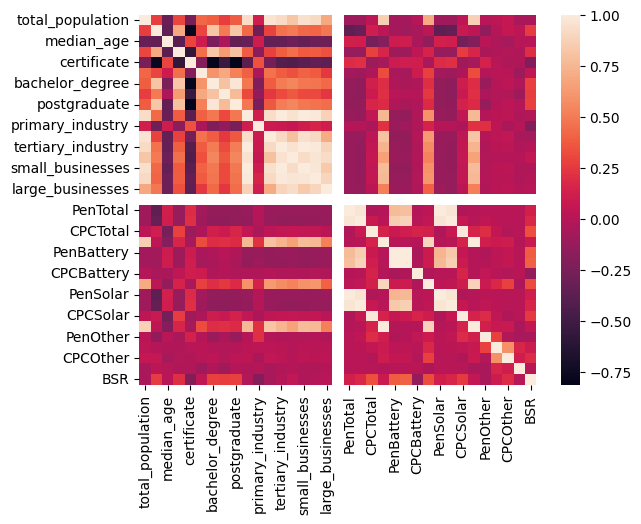

In [309]:
# Plot correlation heatmap
all_var = full_gdf.columns[4:]
socecon_var = lga_df.columns[1:]
energy_var = [var for var in all_var if var not in socecon_var]

corr_df = full_gdf[all_var].corr(method='pearson')
sns.heatmap(data=corr_df)


In [310]:
# Check multicollinearity
from statsmodels.stats.outliers_influence import variance_inflation_factor

X = full_gdf[socecon_var].dropna()
vif = pd.DataFrame()
vif["feature"] = X.columns
vif["VIF"] = [variance_inflation_factor(X.values, i)
              for i in range(X.shape[1])]
print(vif)

                    feature            VIF
0          total_population      38.349333
1        population_density       6.300023
2                median_age      49.865430
3   median_household_income      69.732015
4               certificate      86.873174
5               adv_diploma     110.387575
6           bachelor_degree     202.865506
7          graduate_diploma      27.182842
8              postgraduate      53.817222
9          total_businesses  422934.386851
10         primary_industry    1141.942100
11       secondary_industry   21082.752513
12        tertiary_industry  216145.174088
13      quaternary_industry   14526.092325
14         small_businesses   11883.887310
15        medium_businesses    4192.983158
16         large_businesses      86.226078


From the correlation plot above, we observe that both battery and solar growth rate are correlated with socieconomic variables. 

## Variable Selection


NAs are detected in the data. These NAs are sparse and randomly distributed. We therefore opt to impute these missing values by KNN imputation. 

Variable selection is done by fitting a lasso regression model where cross validation is used to optimise the penalty factor. 
Variables are first standardised before fitting to remove scale bias between variables.  

Once a lasso model is fitted, variables with non-zero coefficients are used for the baseline model. 

In [311]:
# --- Impute Missing Data --- #

from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler

# Copy data to impute
X_df = full_gdf[full_gdf.columns[4:]].copy()

# Scale first 
scaler = StandardScaler()
X_sdf = pd.DataFrame(scaler.fit_transform(X_df), columns=X_df.columns)

#KNN imputation
knn_imp = KNNImputer(n_neighbors=5)
Xknn_sdf = pd.DataFrame(knn_imp.fit_transform(X_sdf), columns=X_df.columns)

# Inverse transform back to original scale
Xknn_df = pd.DataFrame(scaler.inverse_transform(Xknn_sdf), columns=X_df.columns)

# Reattach to LGAs
full_clean_gdf = pd.concat(objs= [full_gdf[['lga']],Xknn_df], axis=1)


# Recheck NAs
full_clean_gdf.isna().sum()

lga                        0
total_population           0
population_density         0
median_age                 0
median_household_income    0
certificate                0
adv_diploma                0
bachelor_degree            0
graduate_diploma           0
postgraduate               0
total_businesses           0
primary_industry           0
secondary_industry         0
tertiary_industry          0
quaternary_industry        0
small_businesses           0
medium_businesses          0
large_businesses           0
year                       0
PenTotal                   0
CPDTotal                   0
CPCTotal                   0
GrowthTotal                0
PenBattery                 0
CPDBattery                 0
CPCBattery                 0
GrowthBattery              0
PenSolar                   0
CPDSolar                   0
CPCSolar                   0
GrowthSolar                0
PenOther                   0
CPDOther                   0
CPCOther                   0
GrowthOther   

In [312]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LassoCV
from sklearn.pipeline import make_pipeline

# Variables
X_var = [
    'total_population', 'population_density', 'median_age',
    'graduate_diploma', 'postgraduate', 'total_businesses',
    'primary_industry', 'secondary_industry', 'tertiary_industry',
    'quaternary_industry', 'small_businesses', 'medium_businesses',
    'large_businesses'
]

X = full_clean_gdf[X_var]
y = full_clean_gdf['GrowthSolar']

# Pipeline: scaling + LassoCV
model = make_pipeline(
    StandardScaler(),
    LassoCV(cv=5, random_state=42, max_iter=10000)  # LassoCV selects optimal lambda via cross-validation automatically
)

model.fit(X, y)

lasso = model.named_steps['lassocv']

print(f"Optimal alpha: {lasso.alpha_:.4f}")

coeffs = pd.Series(lasso.coef_, index=X_var)
print(coeffs.sort_values())

Optimal alpha: 198.7855
population_density     -4209.464394
postgraduate           -3106.694657
secondary_industry     -2620.817567
large_businesses       -1759.504845
median_age               -37.124680
total_businesses          -0.000000
tertiary_industry         -0.000000
quaternary_industry        0.000000
small_businesses          -0.000000
primary_industry        1134.353462
medium_businesses       3211.740100
graduate_diploma        3429.631552
total_population       24757.553869
dtype: float64


/Users/hoseawondo/NextCloud/Projects/PortfolioProjects/Energy/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.394e+07, tolerance: 2.312e+07
  model = cd_fast.enet_coordinate_descent_gram(


## Baseline Model

We fit a baseline model using the variables with non-zero coefficients in the Lasso model. 

In [313]:
def train_model(X_var, print_out=True):
    # Define predictors and outcome
    X = full_clean_gdf[X_var]  
    y = full_clean_gdf['GrowthSolar'] 

    # Add constant (intercept)
    X = sm.add_constant(X)
    
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

    # Cross Validation 
    model_sk = LinearRegression()
    cv_results = cross_validate(
        model_sk, X, y,
        cv=5,
        scoring='neg_mean_squared_error',
        return_train_score=True
    )

    train_rmse = np.sqrt(-cv_results['train_score'].mean())
    val_rmse   = np.sqrt(-cv_results['test_score'].mean())

    # Statsmodel for AIC/BIC
    model = sm.OLS(y, X).fit()
    
    # Print outputs
    if print_out:
        print(f'AIC/BIC: {model.aic:.3f}/{model.bic:.3f}')
        print(f'Train RMSE: {train_rmse:.3f}')
        print(f'Val RMSE:   {val_rmse:.3f}')

        print(model.summary())
    
    return model



In [314]:
X_var = ['total_population', 'population_density','graduate_diploma', 
       'primary_industry', 'postgraduate']

# Create baseline model 
baseline = train_model(X_var, print_out=True)

AIC/BIC: 7657.144/7680.394
Train RMSE: 10745.855
Val RMSE:   15379.140
                            OLS Regression Results                            
Dep. Variable:            GrowthSolar   R-squared:                       0.819
Model:                            OLS   Adj. R-squared:                  0.817
Method:                 Least Squares   F-statistic:                     317.0
Date:                Tue, 12 May 2026   Prob (F-statistic):          1.44e-127
Time:                        03:03:40   Log-Likelihood:                -3822.6
No. Observations:                 356   AIC:                             7657.
Df Residuals:                     350   BIC:                             7680.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------

From the diagnostics above, we see:
- About 80% of the variation in GrowthSolar is explained by the predictors
- Moderate gap between Validation RMSE vs Train RMSE.
- High condition number indicating high multicolinearity. This is not surprising since most factors are likely driven by population size. 
- Non-normal residuals from Jarque-Bera score.

To test spatial autocorrelation in the residuals, we apply Morans I. 

In [315]:
# Global Moran I on residuals
moran = Moran(baseline.resid, w) #

print(f"Moran's I:  {moran.I:.4f}")
print(f"Expected Moran's I:  {moran.EI:.4f}")
print(f"p-value:    {moran.p_sim:.4f}")  # permutation test


Moran's I:  0.4811
Expected Moran's I:  -0.0028
p-value:    0.0010


The global Moran's I test indicates significant spatial autocorrelation in the residuals. 

## Spatial Error Model Refinement

The source of the spatial autocorrelation can be identified using a Lagrange Multiplier test. This determines the type of spatial extension model we should fit. 

In [316]:
from spreg import OLS

X_var = ['total_population', 'population_density','graduate_diploma', 
       'primary_industry', 'postgraduate']

# Define predictors and outcome
X = full_clean_gdf[X_var]  
y = full_clean_gdf['GrowthSolar'] 

# Add constant (intercept)
X = sm.add_constant(X)

# Standarise  
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

model_sp = OLS(
    y.values.reshape(-1, 1),
    X_scaled.values,
    w=w,
    spat_diag=True,  
    name_y='GrowthSolar',
    name_x=list(X_scaled.columns),
    name_w='queen_weights'
)

# Model diagnostics 
print(model_sp.summary)

REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: ORDINARY LEAST SQUARES
------------------------------------------------------------------------------------
Data set            :     unknown
Weights matrix      :queen_weights
Dependent Variable  : GrowthSolar                Number of Observations:         356
Mean dependent var  :  11758.6088                Number of Variables   :           6
S.D. dependent var  :  26238.8568                Degrees of Freedom    :         350
R-squared           :      0.8191
Adjusted R-squared  :      0.8165
Sum squared residual: 4.42083e+10                F-statistic           :    317.0016
Sigma-square        :126309312.547                Prob(F-statistic)     :  1.441e-127
S.E. of regression  :   11238.742                Log likelihood        :   -3822.572
Sigma-square ML     :124180503.909                Akaike info criterion :    7657.144
S.E of regression ML:  11143.6306                Schwarz criterion     :    7680.394

--------------

Both the Lagrange Multiplier (lag) and Lagrange Multiplier (error) are significant. Looking at the robust variants, we see that only the error component is significant. We therefore fit a SEM (Spatial Error Model). 

### SEM Model 

In [317]:
from spreg import GM_Error

sem_model = GM_Error(
    y.values.reshape(-1, 1),
    X_scaled.values,
    w=w,
    name_y='GrowthSolar',
    name_x=list(X_scaled.columns),
    name_w='queen_weights'
)

print(sem_model.summary)

GM_Error
REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: GM SPATIALLY WEIGHTED LEAST SQUARES
------------------------------------------------------------------------------------
Data set            :     unknown
Weights matrix      :queen_weights
Dependent Variable  : GrowthSolar                Number of Observations:         356
Mean dependent var  :  11758.6088                Number of Variables   :           6
S.D. dependent var  :  26238.8568                Degrees of Freedom    :         350
Pseudo R-squared    :      0.7925

------------------------------------------------------------------------------------
            Variable     Coefficient       Std.Error     z-Statistic     Probability
------------------------------------------------------------------------------------
            CONSTANT     11872.01828      2555.83116         4.64507         0.00000
    total_population     24172.93774       600.32493        40.26642         0.00000
  population_density     -46

In [318]:
# Global Moran I on residuals
moran = Moran( sem_model.u, w) #

print(f"Moran's I:  {moran.I:.4f}")
print(f"Expected Moran's I:  {moran.EI:.4f}")
print(f"p-value:    {moran.p_sim:.4f}")  # permutation test


Moran's I:  0.5960
Expected Moran's I:  -0.0028
p-value:    0.0010


The residuals of the SEM model reduced Morans I but still shows significant spatial autocorrelation. We look to fit a Durbin model instead.

### Durbin Model

In [ ]:
X_var = ['total_population', 'population_density','graduate_diploma', 'primary_industry']

# Define predictors and outcome
X = full_clean_gdf[X_var]  
y = full_clean_gdf['GrowthSolar'] 

# Add constant (intercept)
X = sm.add_constant(X)

# Standarise  
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)


from spreg import ML_Lag

sdm_model = ML_Lag(
    y.values.reshape(-1, 1),
    X_scaled.values,
    w=w,
    slx_lags=1,   # Durbin Model
    name_y='GrowthSolar',
    name_x=list(X_scaled.columns),
    name_w='queen_weights'
)

print(sdm_model.summary)

ML_Lag
REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: MAXIMUM LIKELIHOOD SPATIAL LAG WITH SLX - SPATIAL DURBIN MODEL (METHOD = FULL)
------------------------------------------------------------------------------------
Data set            :     unknown
Weights matrix      :queen_weights
Dependent Variable  : GrowthSolar                Number of Observations:         356
Mean dependent var  :  11758.6088                Number of Variables   :          10
S.D. dependent var  :  26238.8568                Degrees of Freedom    :         346
Pseudo R-squared    :      0.8966
Spatial Pseudo R-squared:  0.8193
Log likelihood      :  -3743.5098
Sigma-square ML     :71157030.1525                Akaike info criterion :    7507.020
S.E of regression   :   8435.4627                Schwarz criterion     :    7545.769

------------------------------------------------------------------------------------
            Variable     Coefficient       Std.Error     z-Statistic     Probability
---

/Users/hoseawondo/NextCloud/Projects/PortfolioProjects/Energy/.venv/lib/python3.12/site-packages/numpy/linalg/_linalg.py:2406: RuntimeWarning: divide by zero encountered in det
  r = _umath_linalg.det(a, signature=signature)
/Users/hoseawondo/NextCloud/Projects/PortfolioProjects/Energy/.venv/lib/python3.12/site-packages/numpy/linalg/_linalg.py:2406: RuntimeWarning: overflow encountered in det
  r = _umath_linalg.det(a, signature=signature)
/Users/hoseawondo/NextCloud/Projects/PortfolioProjects/Energy/.venv/lib/python3.12/site-packages/numpy/linalg/_linalg.py:2406: RuntimeWarning: invalid value encountered in det
  r = _umath_linalg.det(a, signature=signature)


In [320]:
# Global Moran I on residuals
moran = Moran( sdm_model.u, w) #

print(f"Moran's I:  {moran.I:.4f}")
print(f"Expected Moran's I:  {moran.EI:.4f}")
print(f"p-value:    {moran.p_sim:.4f}")  # permutation test


Moran's I:  -0.0515
Expected Moran's I:  -0.0028
p-value:    0.0720


Despite the residuals having statically significant spatial autocorrelation in irs residuals, the Spatial Durbin model has significantly reduced the Moran's I statistic. We therefore take this model as the spatial informed solar growth rate model.  